In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [7]:
df = pd.read_excel("C:/Users/JunhuiHuTEST/PycharmProjects/Northeastern/aly6040/week2/mushrooms.xlsx")

In [8]:
print(df.head())
print(df.info())

  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

In [11]:
# Encode all categorical variables to numerical
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])
print(df.head())
# use One-Hot, 0 represnt poison mushroom and 1 represent mushroom without poison
X = df.drop('class', axis=1)
y = df['class']

# separate training dataset and test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      1          5            2          4        1     6                1   
1      0          5            2          9        1     0                1   
2      0          0            2          8        1     3                1   
3      1          5            3          8        1     6                1   
4      0          5            2          3        0     5                1   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
0             0          1           4  ...                         2   
1             0          0           4  ...                         2   
2             0          0           5  ...                         2   
3             0          1           5  ...                         2   
4             1          0           4  ...                         2   

   stalk-color-above-ring  stalk-color-below-ring  veil-type  veil-color  \
0         

In [24]:
# GBM model
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.01, max_depth=5, random_state=42)

# fit with training data
gbm.fit(X_train, y_train)
# predict and summary
gbmpredict = gbm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, gbmpredict))
print(confusion_matrix(y_test, gbmpredict))
print(classification_report(y_test, gbmpredict))


Accuracy: 0.9922067268252666
[[1257    0]
 [  19 1162]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1257
           1       1.00      0.98      0.99      1181

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



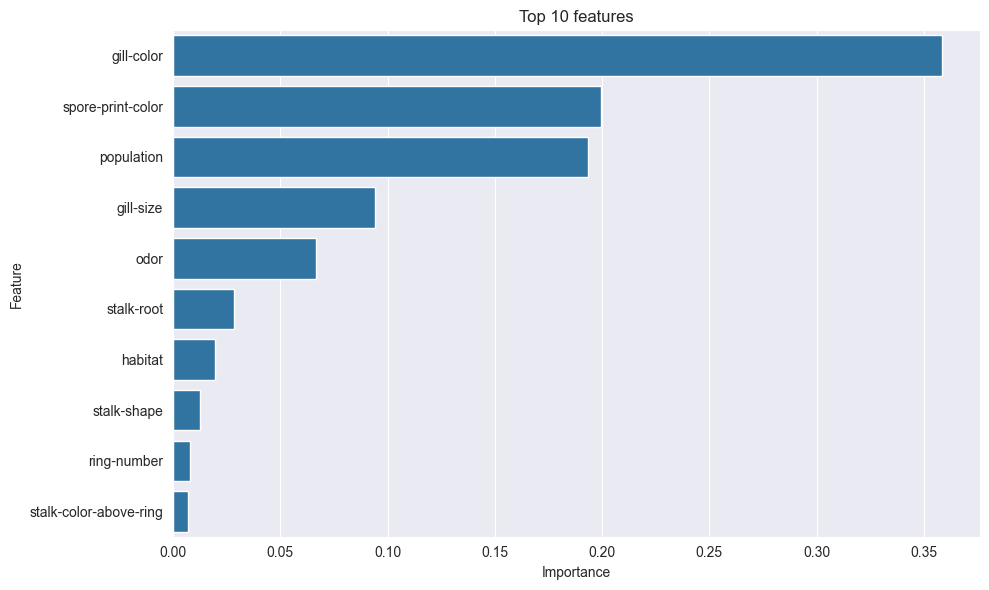

In [25]:
#what are top 10 features
importances = gbm.feature_importances_
indices = np.argsort(importances)[::-1][:10]
features = X.columns[indices]
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=features)
plt.title('Top 10 features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [43]:
df['class'].value_counts(normalize=True)

class
0    0.517971
1    0.482029
Name: proportion, dtype: float64

In [42]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [1, 3, 5]
}

grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation accuracy:", grid.best_score_)

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 200}
Best cross-validation accuracy: 1.0


In [48]:
# adjust the model with the best parameter
best_gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
best_gbm.fit(X_test, y_test)
best_gbmpredict = best_gbm.predict(X_test)
#print out the result
print("Final Accuracy:", accuracy_score(y_test, best_gbmpredict))
print(confusion_matrix(y_test, best_gbmpredict))
print(classification_report(y_test, best_gbmpredict))

Final Accuracy: 1.0
[[1257    0]
 [   0 1181]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1257
           1       1.00      1.00      1.00      1181

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438

